In [1]:
from google.colab import files
uploaded = files.upload()

Saving income_random_forest.csv to income_random_forest.csv


   Age  EducationYears  HoursPerWeek  Experience  Income
0   37              12            44          12       0
1   46              19            58          33       1
2   53              10            54          24       0
3   46              11            22           6       0
4   36              17            56           3       1
Initial Accuracy: 1.0


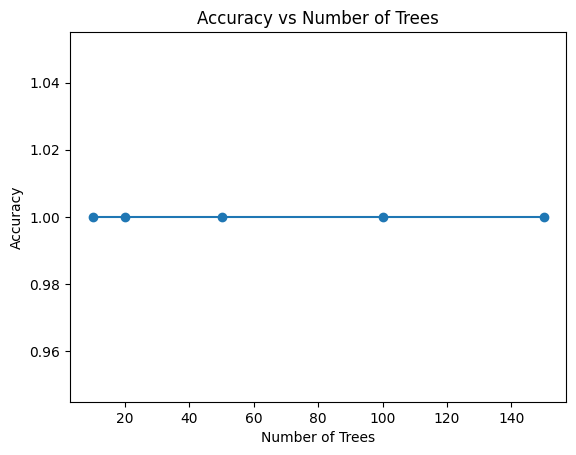

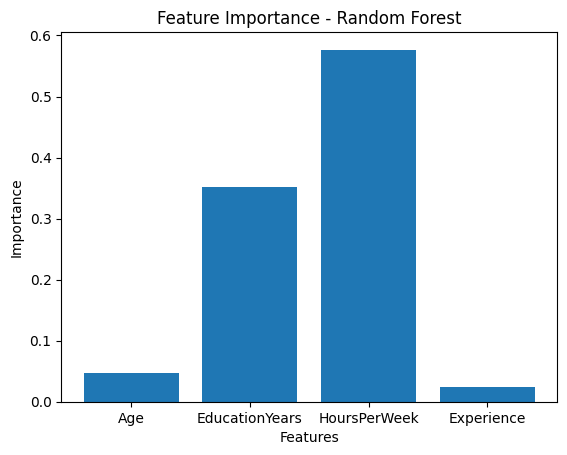

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# -------------------------------
# 1. Load Dataset
# -------------------------------
df = pd.read_csv("income_random_forest.csv")

print(df.head())

# -------------------------------
# 2. Preprocessing
# -------------------------------
# Convert target variable (Income) to numeric
le = LabelEncoder()
df['Income'] = le.fit_transform(df['Income'])  # <=50K = 0, >50K = 1

# -------------------------------
# 3. Features and Target
# -------------------------------
X = df[['Age', 'EducationYears', 'HoursPerWeek', 'Experience']]
y = df['Income']

# -------------------------------
# 4. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 5. Train Random Forest (Initial)
# -------------------------------
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Initial Accuracy:", accuracy)

# -------------------------------
# 6. Tune Number of Trees
# -------------------------------
tree_range = [10, 20, 50, 100, 150]
accuracies = []

for n in tree_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# -------------------------------
# 7. Accuracy vs Number of Trees Graph
# -------------------------------
plt.figure()
plt.plot(tree_range, accuracies, marker='o')
plt.title("Accuracy vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.show()

# -------------------------------
# 8. Feature Importance
# -------------------------------
importances = rf_model.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()